In [5]:
import numpy as np 
import pandas as pd 
import tensorflow as tf
import matplotlib.pyplot as plt
import sklearn as sk 
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler    


In [ ]:
data_0=pd.read_csv('AI_in_HealthCare_Dataset.csv')
data_0.head()
data_0.info()
data_0.describe()
data_0.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               5000 non-null   int64  
 1   Age                      5000 non-null   int64  
 2   Gender                   5000 non-null   object 
 3   Blood_Pressure           5000 non-null   float64
 4   Heart_Rate               5000 non-null   float64
 5   Temperature              5000 non-null   float64
 6   Diagnosis                5000 non-null   object 
 7   Medication               5000 non-null   object 
 8   Treatment_Duration       5000 non-null   int64  
 9   Insurance_Type           5000 non-null   object 
 10  Doctor_Name              5000 non-null   object 
 11  Hospital_Name            5000 non-null   object 
 12  Lab_Test_Results         5000 non-null   float64
 13  X-ray_Results            5000 non-null   object 
 14  Surgery_Type            

,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Temperature,Diagnosis,Medication,Treatment_Duration,Insurance_Type,Doctor_Name,Hospital_Name,Lab_Test_Results,X-ray_Results,Surgery_Type,Recovery_Time,Allergies,Family_History,Patient_Satisfaction,AI_Diagnosis_Confidence
0,1,62,Female,102.349134,79.827209,98.912361,Hypertension,Statins,24,Uninsured,Dr. Brown,Children's Hospital,114.906151,Abnormal,Appendectomy,5,Latex,Heart Disease,3,0.917404
1,2,65,Male,137.760933,72.817449,98.912508,Hypertension,Insulin,29,Uninsured,Dr. Wang,Healthcare Clinic,88.556974,Normal,Knee Replacement,2,Shellfish,Diabetes,4,0.811706
2,3,82,Male,97.618564,57.135424,99.189728,Influenza,Chemotherapy,15,Private,Dr. Johnson,Children's Hospital,106.705047,Normal,Gallbladder Removal,7,NaN,Hypertension,2,0.802673
3,4,85,Male,121.743752,67.355838,96.033487,Heart Disease,Chemotherapy,5,Private,Dr. Smith,Healthcare Clinic,83.043268,Normal,Cataract Surgery,7,Latex,Hypertension,5,0.816811
4,5,85,Male,129.530450,64.849416,99.077675,Heart Disease,Insulin,10,Private,Dr. Lee,Children's Hospital,85.543826,Abnormal,Appendectomy,9,Shellfish,Diabetes,1,0.750850


In [ ]:
data_0["Allergies"].isnull().sum()
data_0["Allergies"].fillna("NULL", inplace=True)
data_0["Allergies"].isnull().sum()
data_0.value_counts("Allergies")

Allergies
Shellfish     1039
Latex         1034
Penicillin     994
Peanuts        969
NULL           964
Name: count, dtype: int64

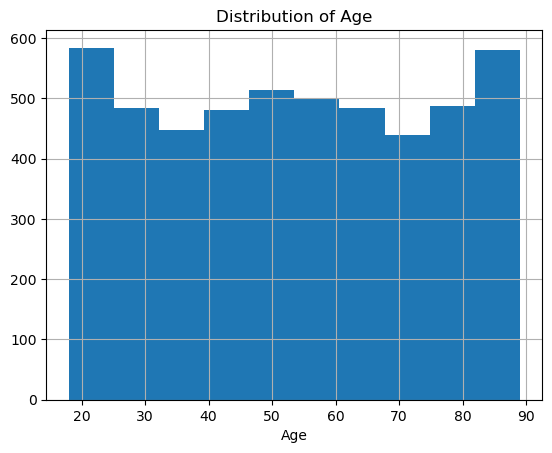

In [18]:
data_0.hist(column="Age", bins=10)
plt.xlabel("Age")
plt.title("Distribution of Age")
plt.show()

In [23]:
data_0['Gender'].value_counts()

Gender
Female    2535
Male      2465
Name: count, dtype: int64

In [ ]:
print(data_0.value_counts("Allergies"))
print("===============================")
print(data_0.value_counts("Diagnosis"))
print("===============================")
print(data_0.value_counts("Medication"))
print("===============================")
print(data_0.value_counts("Insurance_Type"))
print("===============================")
print(data_0.value_counts("Doctor_Name"))
print("===============================")
print(data_0.value_counts("Hospital_Name"))


Allergies
Shellfish     1039
Latex         1034
Penicillin     994
Peanuts        969
Name: count, dtype: int64
Diagnosis
Heart Disease    1069
Cancer           1003
Diabetes         1003
Influenza         997
Hypertension      928
Name: count, dtype: int64
Medication
Aspirin         1021
Antibiotics     1020
Chemotherapy    1017
Statins          980
Insulin          962
Name: count, dtype: int64
Insurance_Type
Private      1295
Uninsured    1243
Medicaid     1234
Medicare     1228
Name: count, dtype: int64
Doctor_Name
Dr. Johnson    1018
Dr. Lee        1017
Dr. Smith       997
Dr. Wang        988
Dr. Brown       980
Name: count, dtype: int64
Hospital_Name
Children's Hospital    1028
City Medical Center    1018
Regional Hospital      1001
Healthcare Clinic       981
General Hospital        972
Name: count, dtype: int64
Lab_Test_Results
24.567602     1
108.898956    1
108.924188    1
108.921255    1
108.916795    1
             ..
91.692746     1
91.679329     1
91.656255     1
91.64473